# Week 7 Video 6: k-Nearest Neighbors (k-NN) Implementation

## Predicting Titanic Survival with k-NN

In this notebook, we'll implement a k-Nearest Neighbors classifier to predict passenger survival on the Titanic. We'll cover:

1. **Import Libraries** - Loading the necessary tools
2. **Load & Explore Data** - Understanding our dataset
3. **Preprocess Data** - Cleaning and encoding features
4. **Feature Scaling** - Critical for k-NN!
5. **Train-Test Split** - Preparing for model training
6. **Train Initial Model** - Starting with k=3
7. **Find Optimal k** - Testing different values
8. **Train Final Model** - Using the best k
9. **Evaluate Performance** - Measuring accuracy and more
10. **Interpret Results** - Understanding what the model learned

---
## Step 1: Import Libraries

We need several libraries for this implementation:
- **pandas**: Data manipulation and analysis
- **numpy**: Numerical operations
- **sklearn**: Machine learning tools (model, splitting, scaling, metrics)
- **matplotlib/seaborn**: Visualization

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


---
## Step 2: Load and Explore the Dataset

Let's load the Titanic dataset and understand what we're working with.

In [2]:
# Load the Titanic dataset
df = pd.read_csv('titanic.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print(f"\nRows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\n" + "="*50)
print("First 5 rows:")
df.head()

Dataset Shape: (891, 12)

Rows: 891, Columns: 12

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Check for missing values
print("Missing Values per Column:")
print("="*35)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
print(missing_df[missing_df['Missing'] > 0])

Missing Values per Column:
          Missing  Percent
Age           177     19.9
Cabin         687     77.1
Embarked        2      0.2


---
## Step 3: Data Preprocessing

We need to:
1. Handle missing values
2. Convert categorical variables to numerical
3. Select relevant features

In [4]:
# Create a copy for preprocessing
data = df.copy()

# 1. Handle missing values
data['Age'].fillna(data['Age'].median(), inplace=True)
data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)

# 2. Convert categorical to numerical
data['Sex'] = data['Sex'].map({'male': 0, 'female': 1})
data['Embarked'] = data['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# 3. Select features for our model
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
target = 'Survived'

print("Features selected:", features)
print("Target variable:", target)
print("\nPreprocessed data sample:")
data[features + [target]].head()

Features selected: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
Target variable: Survived

Preprocessed data sample:


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,3,0,22.0,1,0,7.2500,0,0
1,1,1,38.0,1,0,71.2833,1,1
2,3,1,26.0,0,0,7.9250,0,1
3,1,1,35.0,1,0,53.1000,0,1
4,3,0,35.0,0,0,8.0500,0,0


---
## Step 4: Feature Scaling (Critical for k-NN!)

**Why is scaling important for k-NN?**

k-NN uses distance to find neighbors. Without scaling:
- `Fare` ranges from 0 to 512
- `Age` ranges from 0 to 80
- `Pclass` ranges from 1 to 3

Fare would dominate the distance calculation! We use StandardScaler to give all features equal importance.

In [5]:
# Prepare features (X) and target (y)
X = data[features]
y = data[target]

print("Before Scaling:")
print(X.describe().round(2).loc[['min', 'max', 'mean', 'std']])

Before Scaling:
      Pclass   Sex    Age  SibSp  Parch    Fare  Embarked
min     1.00  0.00   0.42   0.00   0.00    0.00      0.00
max     3.00  1.00  80.00   8.00   6.00  512.33      2.00
mean    2.31  0.35  29.36   0.52   0.38   32.20      0.36
std     0.84  0.48  13.02   1.10   0.81   49.69      0.64


In [6]:
# Apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features)

print("After Scaling (StandardScaler):")
print(X_scaled.describe().round(2).loc[['min', 'max', 'mean', 'std']])

After Scaling (StandardScaler):
      Pclass   Sex   Age  SibSp  Parch  Fare  Embarked
min    -1.57 -0.74 -2.22  -0.47  -0.47 -0.65     -0.57
max     0.83  1.36  3.89   6.78   6.97  9.67      2.58
mean   -0.00  0.00  0.00   0.00   0.00  0.00     -0.00
std     1.00  1.00  1.00   1.00   1.00  1.00      1.00


---
## Step 5: Train-Test Split

We split the data into:
- **Training set (70%)**: Used to train the model
- **Test set (30%)**: Used to evaluate performance on unseen data

In [7]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.3, 
    random_state=42
)

print("Data Split Summary:")
print("="*35)
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X_scaled)*100:.0f}%)")
print(f"Test set:     {X_test.shape[0]} samples ({X_test.shape[0]/len(X_scaled)*100:.0f}%)")
print(f"\nFeatures: {X_train.shape[1]}")
print(f"\nTarget distribution (Training):")
print(y_train.value_counts().to_frame('Count').rename(index={0: 'Not Survived', 1: 'Survived'}))

Data Split Summary:
Training set: 623 samples (70%)
Test set:     268 samples (30%)

Features: 7

Target distribution (Training):
              Count
Survived           
Not Survived    392
Survived        231


---
## Step 6: Train Initial k-NN Model (k=3)

Let's start with k=3 as our initial model. Remember from the theory:
- Small k → More sensitive to noise (potential overfitting)
- We'll use an odd number to avoid ties

In [8]:
# Create and train initial k-NN model with k=3
knn_initial = KNeighborsClassifier(n_neighbors=3)
knn_initial.fit(X_train, y_train)

# Calculate initial accuracy
train_acc_initial = knn_initial.score(X_train, y_train)
test_acc_initial = knn_initial.score(X_test, y_test)

print("Initial k-NN Model (k=3)")
print("="*35)
print(f"Training Accuracy: {train_acc_initial:.2%}")
print(f"Test Accuracy:     {test_acc_initial:.2%}")
print(f"\nGap: {(train_acc_initial - test_acc_initial):.2%}")
if train_acc_initial - test_acc_initial > 0.05:
    print("⚠️  Large gap suggests possible overfitting!")

Initial k-NN Model (k=3)
Training Accuracy: 85.87%
Test Accuracy:     79.10%

Gap: 6.77%
⚠️  Large gap suggests possible overfitting!


---
## Step 7: Finding the Optimal k

We need to test different values of k to find the one that:
1. Gives good test accuracy
2. Has minimal gap between training and test accuracy (no overfitting)

We'll test k from 1 to 30 and visualize the results.

In [9]:
# Test different values of k
k_range = range(1, 31)
train_accuracies = []
test_accuracies = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_accuracies.append(knn.score(X_train, y_train))
    test_accuracies.append(knn.score(X_test, y_test))

# Create results dataframe
results = pd.DataFrame({
    'k': list(k_range),
    'Train Accuracy': train_accuracies,
    'Test Accuracy': test_accuracies
})
results['Gap'] = results['Train Accuracy'] - results['Test Accuracy']

# Find optimal k (best test accuracy among odd numbers)
odd_results = results[results['k'] % 2 == 1]
optimal_k = odd_results.loc[odd_results['Test Accuracy'].idxmax(), 'k']

print(f"Top 5 k values by Test Accuracy (odd numbers only):")
print(odd_results.nlargest(5, 'Test Accuracy')[['k', 'Train Accuracy', 'Test Accuracy', 'Gap']].to_string(index=False))
print(f"\n✓ Optimal k = {optimal_k}")

Top 5 k values by Test Accuracy (odd numbers only):
 k  Train Accuracy  Test Accuracy      Gap
15        0.829856       0.809701 0.020154
 5        0.858748       0.805970 0.052778
 9        0.836276       0.805970 0.030306
11        0.834671       0.805970 0.028701
13        0.837881       0.805970 0.031911

✓ Optimal k = 15


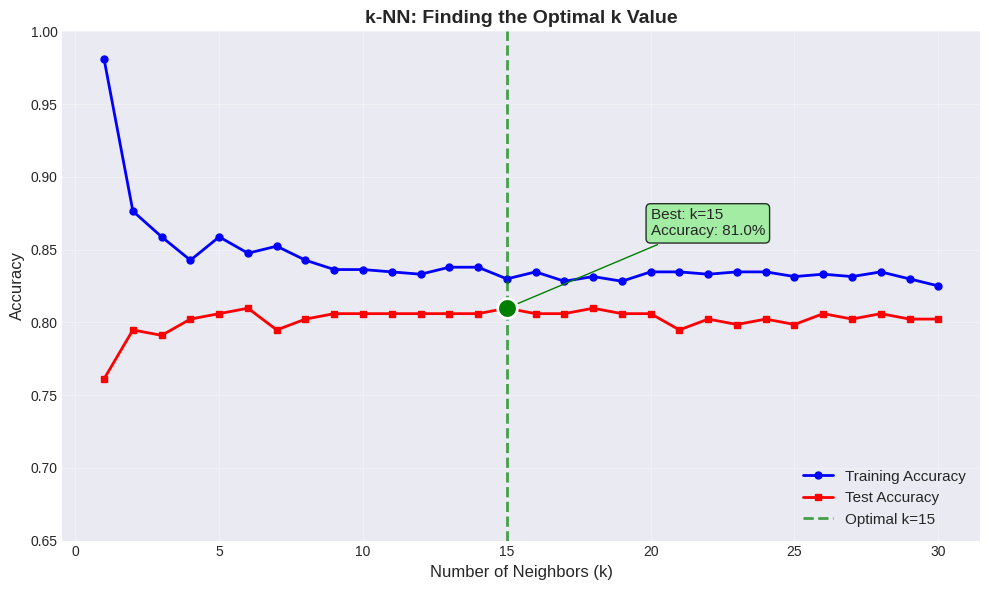


📊 Plot saved as 'knn_accuracy_plot.png'


In [10]:
# Visualize the results
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(k_range, train_accuracies, 'b-o', label='Training Accuracy', markersize=5, linewidth=2)
ax.plot(k_range, test_accuracies, 'r-s', label='Test Accuracy', markersize=5, linewidth=2)

# Highlight optimal k
optimal_idx = int(optimal_k) - 1
ax.axvline(x=optimal_k, color='green', linestyle='--', linewidth=2, alpha=0.7, label=f'Optimal k={optimal_k}')
ax.scatter([optimal_k], [test_accuracies[optimal_idx]], color='green', s=200, zorder=5, edgecolors='white', linewidths=2)

# Labels and formatting
ax.set_xlabel('Number of Neighbors (k)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('k-NN: Finding the Optimal k Value', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.set_xticks(range(0, 31, 5))
ax.set_ylim(0.65, 1.0)
ax.grid(True, alpha=0.3)

# Add annotation
ax.annotate(f'Best: k={optimal_k}\nAccuracy: {test_accuracies[optimal_idx]:.1%}', 
            xy=(optimal_k, test_accuracies[optimal_idx]),
            xytext=(optimal_k + 5, test_accuracies[optimal_idx] + 0.05),
            fontsize=11,
            arrowprops=dict(arrowstyle='->', color='green'),
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

plt.tight_layout()
plt.savefig('knn_accuracy_plot.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n📊 Plot saved as 'knn_accuracy_plot.png'")

---
## Step 8: Train Final Model with Optimal k

Now let's train our final model using the optimal k value we found.

In [11]:
# Train final model with optimal k
knn_final = KNeighborsClassifier(n_neighbors=int(optimal_k))
knn_final.fit(X_train, y_train)

# Make predictions
y_train_pred = knn_final.predict(X_train)
y_test_pred = knn_final.predict(X_test)

# Calculate accuracies
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Final k-NN Model (k={int(optimal_k)})")
print("="*40)
print(f"Training Accuracy: {train_accuracy:.2%}")
print(f"Test Accuracy:     {test_accuracy:.2%}")
print(f"Gap:               {(train_accuracy - test_accuracy):.2%}")

Final k-NN Model (k=15)
Training Accuracy: 82.99%
Test Accuracy:     80.97%
Gap:               2.02%


---
## Step 9: Evaluate Model Performance

Let's evaluate our model using:
1. **Confusion Matrix**: Shows correct and incorrect predictions
2. **Classification Report**: Precision, Recall, F1-Score for each class

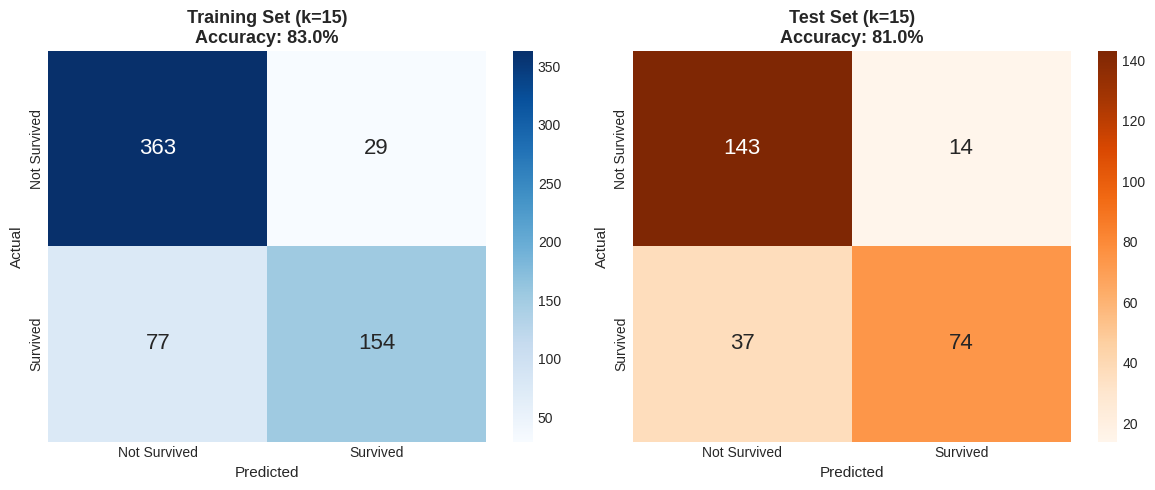


📊 Confusion matrices saved as 'knn_confusion_matrices.png'


In [12]:
# Create confusion matrices
cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Training confusion matrix
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'],
            annot_kws={'size': 16})
axes[0].set_title(f'Training Set (k={int(optimal_k)})\nAccuracy: {train_accuracy:.1%}', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual', fontsize=11)
axes[0].set_xlabel('Predicted', fontsize=11)

# Test confusion matrix
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'],
            annot_kws={'size': 16})
axes[1].set_title(f'Test Set (k={int(optimal_k)})\nAccuracy: {test_accuracy:.1%}', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Actual', fontsize=11)
axes[1].set_xlabel('Predicted', fontsize=11)

plt.tight_layout()
plt.savefig('knn_confusion_matrices.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n📊 Confusion matrices saved as 'knn_confusion_matrices.png'")

In [13]:
# Classification reports
print("="*60)
print("CLASSIFICATION REPORT - TRAINING SET")
print("="*60)
print(classification_report(y_train, y_train_pred, 
                            target_names=['Not Survived (0)', 'Survived (1)']))

print("\n" + "="*60)
print("CLASSIFICATION REPORT - TEST SET")
print("="*60)
print(classification_report(y_test, y_test_pred,
                            target_names=['Not Survived (0)', 'Survived (1)']))

CLASSIFICATION REPORT - TRAINING SET
                  precision    recall  f1-score   support

Not Survived (0)       0.82      0.93      0.87       392
    Survived (1)       0.84      0.67      0.74       231

        accuracy                           0.83       623
       macro avg       0.83      0.80      0.81       623
    weighted avg       0.83      0.83      0.82       623


CLASSIFICATION REPORT - TEST SET
                  precision    recall  f1-score   support

Not Survived (0)       0.79      0.91      0.85       157
    Survived (1)       0.84      0.67      0.74       111

        accuracy                           0.81       268
       macro avg       0.82      0.79      0.80       268
    weighted avg       0.81      0.81      0.81       268



---
## Step 10: Interpret Results and Key Insights

Let's summarize what we learned from our k-NN model.

In [14]:
# Extract metrics for summary
from sklearn.metrics import precision_score, recall_score, f1_score

# Test set metrics
precision_0 = precision_score(y_test, y_test_pred, pos_label=0)
precision_1 = precision_score(y_test, y_test_pred, pos_label=1)
recall_0 = recall_score(y_test, y_test_pred, pos_label=0)
recall_1 = recall_score(y_test, y_test_pred, pos_label=1)
f1_0 = f1_score(y_test, y_test_pred, pos_label=0)
f1_1 = f1_score(y_test, y_test_pred, pos_label=1)

print("="*60)
print("MODEL PERFORMANCE SUMMARY")
print("="*60)
print(f"\n📊 Overall Performance:")
print(f"   • Training Accuracy: {train_accuracy:.1%}")
print(f"   • Test Accuracy:     {test_accuracy:.1%}")
print(f"   • Accuracy Gap:      {(train_accuracy - test_accuracy):.1%}")

print(f"\n📈 Class 0 (Not Survived) - Test Set:")
print(f"   • Precision: {precision_0:.2f}")
print(f"   • Recall:    {recall_0:.2f}")
print(f"   • F1-Score:  {f1_0:.2f}")

print(f"\n📉 Class 1 (Survived) - Test Set:")
print(f"   • Precision: {precision_1:.2f}")
print(f"   • Recall:    {recall_1:.2f}")
print(f"   • F1-Score:  {f1_1:.2f}")

print(f"\n🎯 Key Insights:")
if train_accuracy - test_accuracy < 0.05:
    print(f"   ✓ No significant overfitting (gap < 5%)")
else:
    print(f"   ⚠️ Some overfitting detected (gap >= 5%)")

if recall_0 > recall_1:
    print(f"   • Model better at identifying non-survivors (recall: {recall_0:.0%}) than survivors (recall: {recall_1:.0%})")
else:
    print(f"   • Model better at identifying survivors than non-survivors")

print(f"\n💡 Optimal k = {int(optimal_k)} provides the best balance between bias and variance.")

MODEL PERFORMANCE SUMMARY

📊 Overall Performance:
   • Training Accuracy: 83.0%
   • Test Accuracy:     81.0%
   • Accuracy Gap:      2.0%

📈 Class 0 (Not Survived) - Test Set:
   • Precision: 0.79
   • Recall:    0.91
   • F1-Score:  0.85

📉 Class 1 (Survived) - Test Set:
   • Precision: 0.84
   • Recall:    0.67
   • F1-Score:  0.74

🎯 Key Insights:
   ✓ No significant overfitting (gap < 5%)
   • Model better at identifying non-survivors (recall: 91%) than survivors (recall: 67%)

💡 Optimal k = 15 provides the best balance between bias and variance.


---
## Comparison: k=3 vs Optimal k

Let's compare our initial model (k=3) with the optimized model.

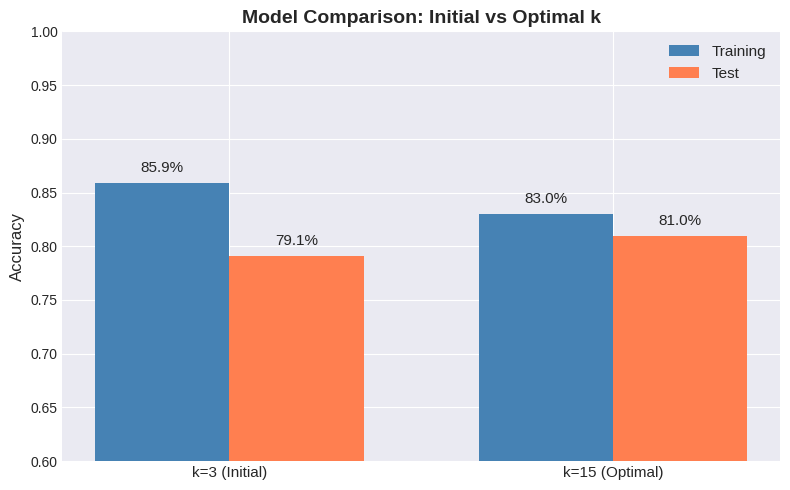


📊 Comparison plot saved as 'knn_comparison.png'


In [15]:
# Create comparison visualization
fig, ax = plt.subplots(figsize=(8, 5))

labels = ['k=3 (Initial)', f'k={int(optimal_k)} (Optimal)']
train_accs = [train_acc_initial, train_accuracy]
test_accs = [test_acc_initial, test_accuracy]

x = np.arange(len(labels))
width = 0.35

bars1 = ax.bar(x - width/2, train_accs, width, label='Training', color='steelblue')
bars2 = ax.bar(x + width/2, test_accs, width, label='Test', color='coral')

ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Model Comparison: Initial vs Optimal k', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0.6, 1.0)

# Add value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{bar.get_height():.1%}', ha='center', fontsize=11)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{bar.get_height():.1%}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('knn_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n📊 Comparison plot saved as 'knn_comparison.png'")

---
## Summary: Key Takeaways

### What We Learned:

1. **Feature Scaling is Critical** - k-NN uses distance, so all features must be on the same scale

2. **Choosing k Matters** - Too small (overfitting) vs too large (underfitting)

3. **Use Odd k Values** - Prevents ties in binary classification

4. **Visualize Train vs Test** - The accuracy plot helps identify the optimal k

5. **Evaluate Both Classes** - Check precision, recall for each class separately

### Model Results:
- **Optimal k**: Found through systematic testing
- **Accuracy**: Consistent between training and test (good generalization)
- **Class Imbalance**: Model performs differently on survived vs non-survived

In [16]:
# Final summary print
print("\n" + "="*60)
print("🎓 WEEK 7-6: k-NN IMPLEMENTATION COMPLETE!")
print("="*60)
print(f"\n✓ Optimal k value: {int(optimal_k)}")
print(f"✓ Final Test Accuracy: {test_accuracy:.1%}")
print(f"✓ Model generalizes well (train-test gap: {(train_accuracy-test_accuracy):.1%})")
print("\n📁 Generated files:")
print("   • knn_accuracy_plot.png")
print("   • knn_confusion_matrices.png")
print("   • knn_comparison.png")


🎓 WEEK 7-6: k-NN IMPLEMENTATION COMPLETE!

✓ Optimal k value: 15
✓ Final Test Accuracy: 81.0%
✓ Model generalizes well (train-test gap: 2.0%)

📁 Generated files:
   • knn_accuracy_plot.png
   • knn_confusion_matrices.png
   • knn_comparison.png
